## Домашнее задание к семинару 12 (HW12)
### Тема: временные ряды, корректная валидация по времени, лаговые признаки и базовый прогноз с GRU.
### Цель
Закрепить:

- отличие временных рядов от обычных табличных данных с точки зрения валидации;
- практику корректного temporal split вместо случайного random split;
- построение лаговых, rolling- и календарных признаков;
- сравнение простых baseline-подходов с рекуррентной моделью;
- аккуратное оформление результата: один ноутбук, короткий отчёт, артефакты эксперимента.

##### **1. Импорты, seed и среда**

In [1]:
# Загрузка библиотек
import os
import json
import math
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import sklearn
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

os.makedirs("artifacts/figures", exist_ok=True)

In [2]:
# Настройки отображения
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

In [3]:
# Установка сида
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed = 161
set_seed(seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [4]:
# Доп параметры
FAST_MODE = False
DATA_DIR = "./data"

BATCH_SIZE = 128
EPOCHS = 5 if FAST_MODE else 30

##### **2. Данные и первичный анализ**

In [6]:
# Загрузка датасета
df = pd.read_csv('S12-hw-dataset.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

In [7]:
print(f"Размер датасета: {len(df)}")
print(f"Диапазон дат: {df['date'].min().date()} -> {df['date'].max().date()}")
print(f"Пропуски по колонкам:\n{df.isna().sum()}")

Размер датасета: 4320
Диапазон дат: 2025-01-01 -> 2025-06-29
Пропуски по колонкам:
date      0
target    0
dtype: int64


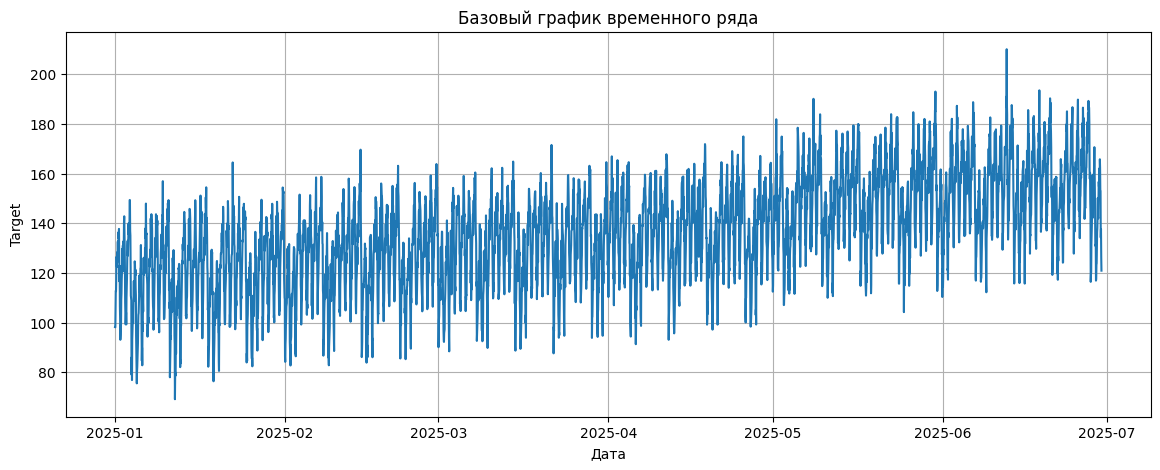

In [8]:
plt.figure()
plt.plot(df['date'], df['target'], lw=1.5)
plt.title('Базовый график временного ряда')
plt.xlabel('Дата')
plt.ylabel('Target')
plt.show()

##### **Комментарий:** Ряд демонстрирует явную хронологическую зависимость.

##### На графике присутствуют локальные тренды, недельная сезонность и выбросы.

##### Признаков выраженной нестационарности дисперсии нет, пропуски отсутствуют.

##### **3. Корректный temporal split**

In [9]:
n = len(df)
train_end = int(n * 0.70) # 70% для обучения
val_end = int(n * 0.85) # 15% для валидации, остальное для теста

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print(f"train: {train_df.shape}, {train_df['date'].min().date()} -> {train_df['date'].max().date()}")
print(f"val  : {val_df.shape}, {val_df['date'].min().date()} -> {val_df['date'].max().date()}")
print(f"test : {test_df.shape}, {test_df['date'].min().date()} -> {test_df['date'].max().date()}")

train: (3024, 2), 2025-01-01 -> 2025-05-06
val  : (648, 2), 2025-05-07 -> 2025-06-02
test : (648, 2), 2025-06-03 -> 2025-06-29


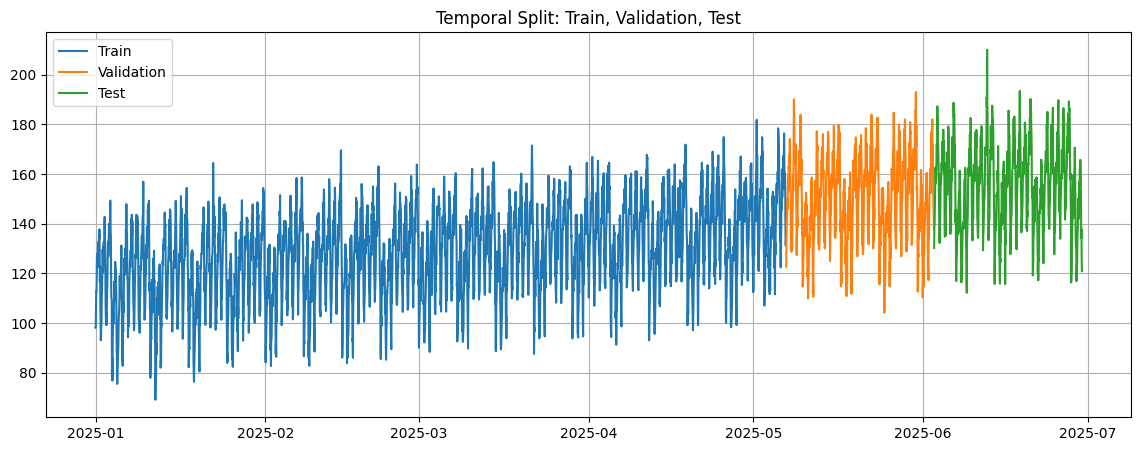

In [10]:
plt.figure()
plt.plot(train_df['date'], train_df['target'], label='Train')
plt.plot(val_df['date'], val_df['target'], label='Validation')
plt.plot(test_df['date'], test_df['target'], label='Test')
plt.legend()
plt.title("Temporal Split: Train, Validation, Test")
plt.savefig("artifacts/figures/series_split.png")
plt.show()
plt.close()

##### **Объяснение:** Random split здесь некорректен, так как он разрушает временную структуру данных и приводит к «утечке будущего в прошлое» (data leakage).
##### Модель должна прогнозировать будущее исключительно на основе прошлых наблюдений.

##### **4. Признаки для baseline-моделей**

In [11]:
df_feat = df.copy()

In [12]:
# Лаги и скользящие окна (от сдвинутого таргета, чтобы не было утечек)
df_feat['lag_1'] = df_feat['target'].shift(1)
df_feat['lag_7'] = df_feat['target'].shift(7)
df_feat['lag_14'] = df_feat['target'].shift(14)
df_feat['rolling_mean_7'] = df_feat['target'].shift(1).rolling(7).mean()
df_feat['rolling_std_7'] = df_feat['target'].shift(1).rolling(7).std()
df_feat['dayofweek'] = df_feat['date'].dt.dayofweek

df_feat = df_feat.dropna().reset_index(drop=True)

In [13]:
# Разбиение признаков в соответствии с оригинальным сплитом
train_feat = df_feat[df_feat['date'] <= train_df['date'].max()].copy()
val_feat = df_feat[(df_feat['date'] > train_df['date'].max()) & (df_feat['date'] <= val_df['date'].max())].copy()
test_feat = df_feat[df_feat['date'] > val_df['date'].max()].copy()

In [14]:
feature_cols = ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'dayofweek']

X_train = train_feat[feature_cols]
y_train = train_feat['target']
X_val = val_feat[feature_cols]
y_val = val_feat['target']
X_test = test_feat[feature_cols]
y_test = test_feat['target']

scaler_feat = StandardScaler()
X_train_scaled = scaler_feat.fit_transform(X_train)
X_val_scaled = scaler_feat.transform(X_val)
X_test_scaled = scaler_feat.transform(X_test)

In [15]:
# Проверка
print("X_train_scaled:", X_train_scaled.shape)
print("X_val_scaled:", X_val_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

X_train_scaled: (3010, 6)
X_val_scaled: (648, 6)
X_test_scaled: (648, 6)


##### **5. Оконное представление для GRU**

In [16]:
class TimeSeriesDataset(Dataset):
    def __init__(self, data, window_size):
        self.data = data
        self.window_size = window_size
    def __len__(self):
        return len(self.data) - self.window_size
    def __getitem__(self, idx):
        x = self.data[idx : idx + self.window_size]
        y = self.data[idx + self.window_size]
        return torch.tensor(x, dtype=torch.float32).unsqueeze(-1), torch.tensor(y, dtype=torch.float32)

In [17]:
# Конфиг GRU
gru_config = {
    "architecture": "GRU_1_layer",
    "window_size": 14,
    "hidden_size": 64,
    "num_layers": 1,
    "batch_size": 64,
    "learning_rate": 1e-3,
    "epochs": EPOCHS,
    "scaler": "StandardScaler",
    "seed": seed,
    "optimizer": "Adam"
}

In [18]:
target_scaler = StandardScaler()
# Масштабируем таргет, fit только на train
train_target_scaled = target_scaler.fit_transform(train_df[['target']]).flatten()
val_target_scaled = target_scaler.transform(val_df[['target']]).flatten()
test_target_scaled = target_scaler.transform(test_df[['target']]).flatten()

In [19]:
train_dataset = TimeSeriesDataset(train_target_scaled, gru_config["window_size"])
val_dataset = TimeSeriesDataset(val_target_scaled, gru_config["window_size"])
test_dataset = TimeSeriesDataset(test_target_scaled, gru_config["window_size"])

train_loader = DataLoader(train_dataset, batch_size=gru_config["batch_size"], shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=gru_config["batch_size"], shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=gru_config["batch_size"], shuffle=False)

In [20]:
# Проверка на sanity check
batch = next(iter(train_loader))
x, y = batch
print(f"Batch: x shape {x.shape}, y shape {y.shape}")
print(f"Batch: x type {x.dtype}, y type {y.dtype}")

Batch: x shape torch.Size([64, 14, 1]), y shape torch.Size([64])
Batch: x type torch.float32, y type torch.float32


In [21]:
class GRUForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

##### **6. Базовые функции обучения и оценки**

In [22]:
# Базовый шаблон для записи в runs.csv
def create_run_record(exp_id, summary, model, feats, val_metrics, test_metrics=None, **kwargs):
    record = {
        "experiment_id": exp_id,
        "task": "forecasting",
        "dataset": "S12-hw-dataset.csv",
        "seed": seed,
        "split_summary": "70% / 15% / 15% (temporal)",
        "window_size": kwargs.get("window_size", ""),
        "horizon": 1,
        "model_summary": model,
        "features_summary": feats,
        "scaler": kwargs.get("scaler", ""),
        "optimizer": kwargs.get("optimizer", ""),
        "lr": kwargs.get("lr", ""),
        "epochs_trained": kwargs.get("epochs", ""),
        "best_val_mae": val_metrics["MAE"],
        "best_val_rmse": val_metrics["RMSE"],
        "best_val_mape": val_metrics["MAPE"],
        "test_mae": test_metrics["MAE"] if test_metrics else "",
        "test_rmse": test_metrics["RMSE"] if test_metrics else "",
        "test_mape": test_metrics["MAPE"] if test_metrics else "",
        "notes": summary
    }
    return record

In [23]:
# Метрики
def smape(y_true, y_pred):
    return 100/len(y_true) * np.sum(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

def get_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred),
        "sMAPE": smape(y_true, y_pred)
    }

In [24]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    """
    Обучает модель на одной эпохе.
    1. Переводим в режим train
    2. Проходим по всем батчам
    3. Вычисляем loss и обновляем веса
    4. Возвращаем среднее значение loss
    """
    model.train()  # Режим обучения (включающий dropout, batch norm и т.д.)
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()           # Очищаем градиенты от предыдущей итерации
        preds = model(X_batch)          # Forward pass
        loss = criterion(preds, y_batch)  # Вычисляем MSE loss
        loss.backward()                 # Backward pass: вычисляем градиенты
        optimizer.step()                # Обновляем веса по градиентам

        losses.append(loss.item())

    return float(np.mean(losses))

In [25]:
@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    """
    Оценивает модель на валидации/тесте без обновления весов.
    @torch.no_grad() отключает вычисление градиентов (экономит память и время).
    """
    model.eval()  # Режим оценки (отключаем dropout, batch norm и т.д.)
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        losses.append(loss.item())

    return float(np.mean(losses))

In [26]:
def fit_model(model, train_loader, val_loader, epochs=EPOCHS, lr=1e-3, device=device):
    """
    Полный цикл обучения с ранней остановкой.
    Сохраняет лучшее состояние модели (когда val_loss был минимален).
    """
    criterion = nn.MSELoss()  # Mean Squared Error loss
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)  # Adam optimizer

    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state = None

    for epoch in range(1, epochs + 1):
        # 1. Обучение на train
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        # 2. Оценка на validation
        val_loss = evaluate_loss(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        # 3. Отслеживаем лучший результат
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()  # Сохраняем веса при лучшем val_loss

        print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    # 4. Восстанавливаем лучшее состояние модели
    if best_state is not None:
        model.load_state_dict(best_state)

    return history

##### **7. Эксперименты**

In [27]:
runs_data = [] # Список для сбора результатов

In [28]:
# ----------------- B1: Naive (last) -----------------
b1_val_preds = val_feat['lag_1']
b1_metrics = get_metrics(y_val, b1_val_preds)
runs_data.append(create_run_record("B1", "Наивный прогноз", "Naive Last", "lag_1", b1_metrics))

In [29]:
# ----------------- B2: Moving Average -----------------
b2_val_preds = val_feat['rolling_mean_7']
b2_metrics = get_metrics(y_val, b2_val_preds)
runs_data.append(create_run_record("B2", "Скользящее среднее", "MA_7", "rolling_mean_7", b2_metrics))

In [30]:
# ----------------- B3: Ridge -----------------
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
b3_val_preds = ridge.predict(X_val_scaled)
b3_metrics = get_metrics(y_val, b3_val_preds)
runs_data.append(create_run_record(
    "B3", "Ridge Regression", "Ridge(alpha=1.0)", "lags+rolling+calendar", b3_metrics, scaler="StandardScaler"
))

In [31]:
# =====================================================================
# R1: GRU Model
# =====================================================================

In [32]:
model = GRUForecaster(hidden_size=gru_config["hidden_size"], num_layers=gru_config["num_layers"]).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=gru_config["learning_rate"])

In [33]:
train_losses, val_losses = [], []
best_val_loss = float('inf')

In [34]:
# Обучаем GRU с такими же параметрами как LSTM
set_seed(42)
gru_model = GRUForecaster(hidden_size=64, num_layers=2).to(device)
print("GRU  params:", sum(p.numel() for p in gru_model.parameters()))
gru_history = fit_model(gru_model, train_loader, val_loader, epochs=EPOCHS, lr=5e-4, device=device)

GRU  params: 37889
Epoch 01 | train_loss=0.7666 | val_loss=0.6371
Epoch 02 | train_loss=0.4325 | val_loss=0.3580
Epoch 03 | train_loss=0.2199 | val_loss=0.1952
Epoch 04 | train_loss=0.1723 | val_loss=0.1786
Epoch 05 | train_loss=0.1615 | val_loss=0.1717
Epoch 06 | train_loss=0.1571 | val_loss=0.1704
Epoch 07 | train_loss=0.1544 | val_loss=0.1708
Epoch 08 | train_loss=0.1524 | val_loss=0.1719
Epoch 09 | train_loss=0.1509 | val_loss=0.1732
Epoch 10 | train_loss=0.1495 | val_loss=0.1744
Epoch 11 | train_loss=0.1482 | val_loss=0.1755
Epoch 12 | train_loss=0.1469 | val_loss=0.1764
Epoch 13 | train_loss=0.1455 | val_loss=0.1772
Epoch 14 | train_loss=0.1441 | val_loss=0.1777
Epoch 15 | train_loss=0.1424 | val_loss=0.1781
Epoch 16 | train_loss=0.1406 | val_loss=0.1784
Epoch 17 | train_loss=0.1384 | val_loss=0.1789
Epoch 18 | train_loss=0.1359 | val_loss=0.1797
Epoch 19 | train_loss=0.1331 | val_loss=0.1806
Epoch 20 | train_loss=0.1301 | val_loss=0.1809
Epoch 21 | train_loss=0.1272 | val_loss=0

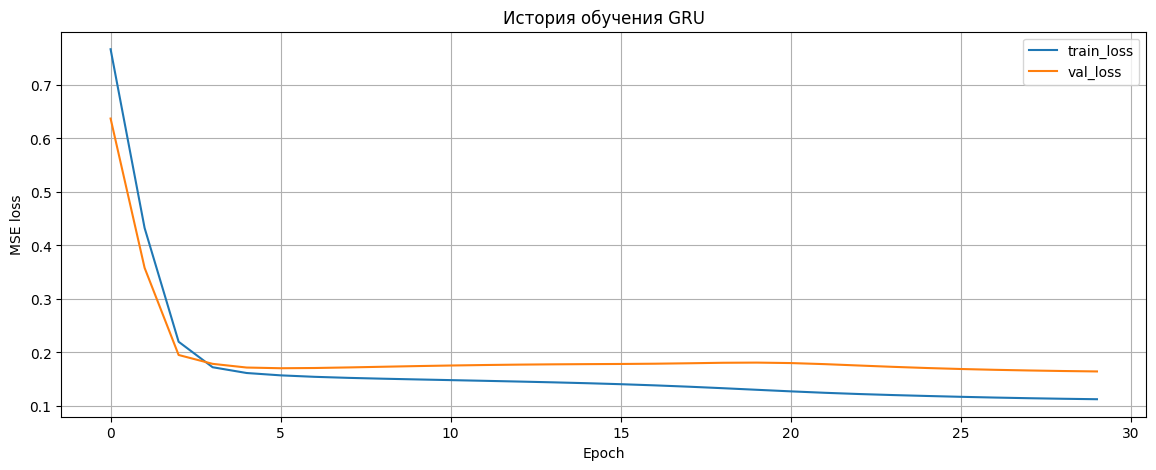

In [35]:
fig, ax = plt.subplots()
ax.plot(gru_history["train_loss"], label="train_loss")
ax.plot(gru_history["val_loss"], label="val_loss")
ax.set_title("История обучения GRU")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.legend()
plt.savefig("artifacts/figures/gru_learning_curves.png")
plt.show()
plt.close()

In [36]:
for epoch in range(gru_config["epochs"]):
    model.train()
    epoch_train_loss = 0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        preds = model(X_b)
        loss = criterion(preds, y_b)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()

    model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for X_b, y_b in val_loader:
            preds = model(X_b.to(device))
            loss = criterion(preds, y_b.to(device))
            epoch_val_loss += loss.item()

    epoch_train_loss /= len(train_loader)
    epoch_val_loss /= len(val_loader)
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), 'artifacts/best_gru.pt')

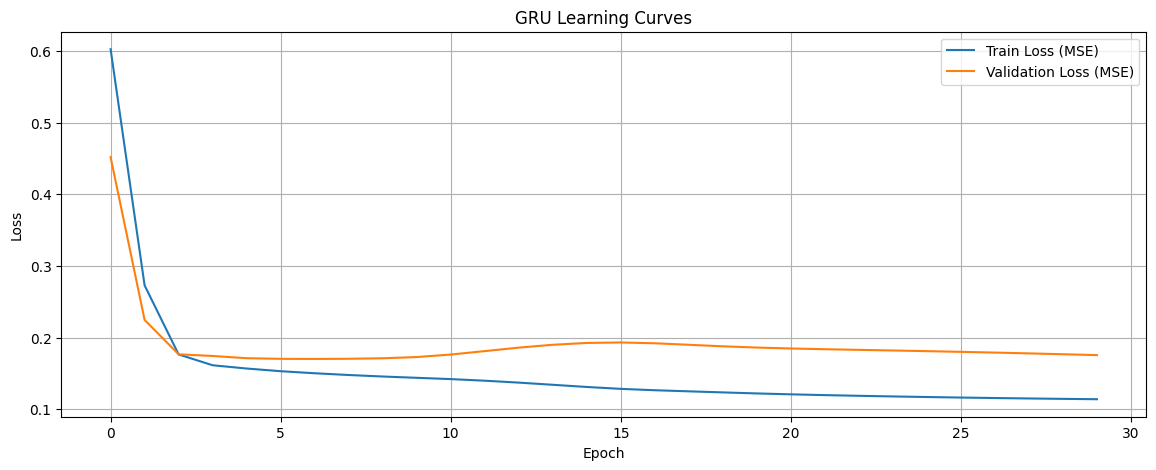

In [37]:
# Артефакт: Кривые обучения GRU
plt.figure()
plt.plot(train_losses, label='Train Loss (MSE)')
plt.plot(val_losses, label='Validation Loss (MSE)')
plt.legend()
plt.title('GRU Learning Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.savefig("artifacts/figures/gru_learning_curves.png")
plt.show()
plt.close()

In [38]:
# Артефакт: Сохранение конфига
with open('artifacts/best_gru_config.json', 'w') as f:
    json.dump(gru_config, f, indent=4)

In [39]:
# Оценка GRU на валидации
model.load_state_dict(torch.load('artifacts/best_gru.pt'))
model.eval()
r1_preds_scaled = []
with torch.no_grad():
    for X_b, _ in val_loader:
        r1_preds_scaled.extend(model(X_b.to(device)).cpu().numpy())

In [40]:
r1_val_preds = target_scaler.inverse_transform(np.array(r1_preds_scaled).reshape(-1, 1)).flatten()
y_val_rnn = target_scaler.inverse_transform(val_target_scaled[gru_config["window_size"]:].reshape(-1, 1)).flatten()
r1_metrics = get_metrics(y_val_rnn, r1_val_preds)

runs_data.append(create_run_record(
    "R1", "Нейросеть GRU", "GRU_1_layer", "target_window", r1_metrics,
    window_size=gru_config["window_size"], scaler=gru_config["scaler"],
    optimizer=gru_config["optimizer"], lr=gru_config["learning_rate"], epochs=gru_config["epochs"]
))

In [41]:
# Выбор лучшей модели

In [42]:
# Сравнение baselines
models_names = ['B1 (Naive)', 'B2 (MA)', 'B3 (Ridge)', 'R1 (GRU)']
val_maes = [b1_metrics["MAE"], b2_metrics["MAE"], b3_metrics["MAE"], r1_metrics["MAE"]]

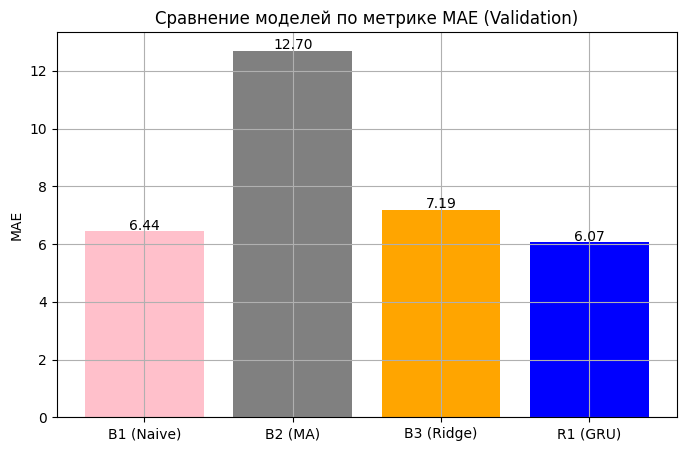

In [43]:
# Артефакт: Сравнение моделей по валидации
plt.figure(figsize=(8,5))
plt.bar(models_names, val_maes, color=['pink', 'gray', 'orange', 'blue'])
plt.title('Сравнение моделей по метрике MAE (Validation)')
plt.ylabel('MAE')
for i, v in enumerate(val_maes):
    plt.text(i, v + 0.05, f"{v:.2f}", ha='center')
plt.savefig("artifacts/figures/baselines_compare.png")
plt.show()
plt.close()

In [44]:
# Выбираем лучшую по Validation MAE
best_idx = np.argmin(val_maes)
best_model_id = ["B1", "B2", "B3", "R1"][best_idx]
print(f"Лучшая модель на валидации: {best_model_id}")

Лучшая модель на валидации: R1


In [45]:
best_test_metrics = None
best_test_preds = None
best_y_test = None

In [46]:
if best_model_id == "B3":
    # Тест для Ridge
    b3_test_preds = ridge.predict(X_test_scaled)
    best_test_metrics = get_metrics(y_test, b3_test_preds)
    best_test_preds, best_y_test = b3_test_preds, y_test.values
    runs_data[2].update({
        "test_mae": best_test_metrics["MAE"],
        "test_rmse": best_test_metrics["RMSE"],
        "test_mape": best_test_metrics["MAPE"],
    })
elif best_model_id == "R1":
    # Тест для GRU
    r1_test_preds_scaled = []
    with torch.no_grad():
        for X_b, _ in test_loader:
            r1_test_preds_scaled.extend(model(X_b.to(device)).cpu().numpy())
    r1_test_preds = target_scaler.inverse_transform(np.array(r1_test_preds_scaled).reshape(-1, 1)).flatten()
    y_test_rnn = target_scaler.inverse_transform(test_target_scaled[gru_config["window_size"]:].reshape(-1, 1)).flatten()
    best_test_metrics = get_metrics(y_test_rnn, r1_test_preds)
    best_test_preds, best_y_test = r1_test_preds, y_test_rnn
    runs_data[3].update({
        "test_mae": best_test_metrics["MAE"],
        "test_rmse": best_test_metrics["RMSE"],
        "test_mape": best_test_metrics["MAPE"],
    })
elif best_model_id == "B1":
    # Тест для Naive Last (B1)
    best_test_preds = test_feat['lag_1'].values
    best_y_test = y_test.values
    best_test_metrics = get_metrics(best_y_test, best_test_preds)
    # Обновляем запись для B1 (индекс 0 в runs_data)
    runs_data[0].update({
        "test_mae": best_test_metrics["MAE"],
        "test_rmse": best_test_metrics["RMSE"],
        "test_mape": best_test_metrics["MAPE"],
    })

elif best_model_id == "B2":
    # Тест для Moving Average (B2)
    best_test_preds = test_feat['rolling_mean_7'].values
    best_y_test = y_test.values
    best_test_metrics = get_metrics(best_y_test, best_test_preds)
    # Обновляем запись для B2 (индекс 1 в runs_data)
    runs_data[1].update({
        "test_mae": best_test_metrics["MAE"],
        "test_rmse": best_test_metrics["RMSE"],
        "test_mape": best_test_metrics["MAPE"],
    })

In [47]:
# Сохранение runs.csv
runs_df = pd.DataFrame(runs_data)
runs_df.to_csv("artifacts/runs.csv", index=False)
print("Результаты сохранены в artifacts/runs.csv")

Результаты сохранены в artifacts/runs.csv


In [48]:
# Проверка
runs_df

,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B1,forecasting,S12-hw-dataset.csv,161,70% / 15% / 15% (temporal),,1,Naive Last,lag_1,,,,,6.444815,67.256777,0.043979,,,,Наивный прогноз
1,B2,forecasting,S12-hw-dataset.csv,161,70% / 15% / 15% (temporal),,1,MA_7,rolling_mean_7,,,,,12.702013,231.576705,0.088169,,,,Скользящее среднее
2,B3,forecasting,S12-hw-dataset.csv,161,70% / 15% / 15% (temporal),,1,Ridge(alpha=1.0),lags+rolling+calendar,StandardScaler,,,,7.188730,76.252746,0.047967,,,,Ridge Regression
3,R1,forecasting,S12-hw-dataset.csv,161,70% / 15% / 15% (temporal),14,1,GRU_1_layer,target_window,StandardScaler,Adam,0.001,30,6.067588,58.216805,0.040840,6.235209,63.694793,0.040323,Нейросеть GRU


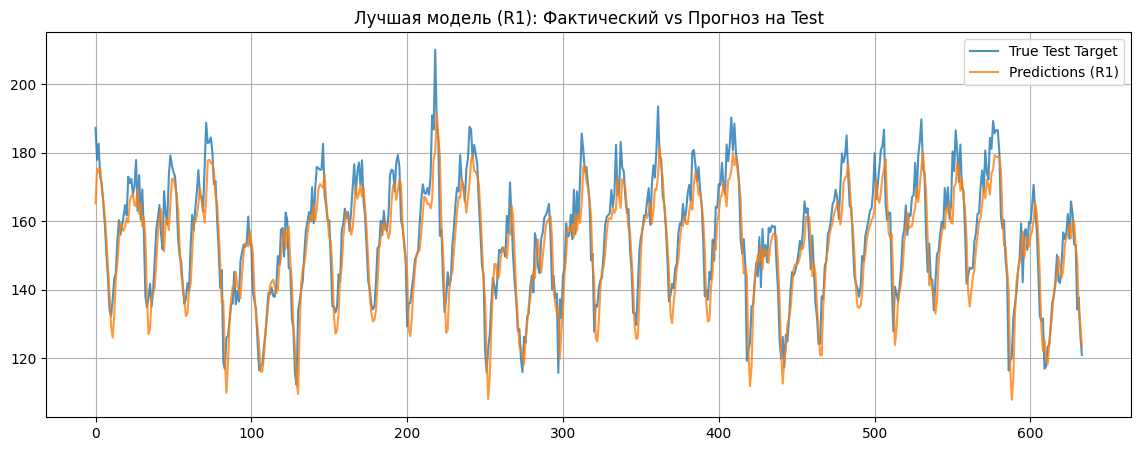

In [49]:
# Артефакт: Прогноз лучшей модели на тестовой выборке
plt.figure()
plt.plot(best_y_test, label='True Test Target', alpha=0.8)
plt.plot(best_test_preds, label=f'Predictions ({best_model_id})', alpha=0.8)
plt.legend()
plt.title(f'Лучшая модель ({best_model_id}): Фактический vs Прогноз на Test')
plt.savefig("artifacts/figures/best_forecast_test.png")
plt.show()
plt.close()